In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

engine = create_engine("postgresql+psycopg://localhost/props")

def q(sql):
    """Shortcut to run SQL and get a DataFrame."""
    return pd.read_sql(sql, engine)

In [11]:
q("""
SELECT sport_code, COUNT(*) AS games, MIN(game_date), MAX(game_date)
FROM games
GROUP BY sport_code
ORDER BY sport_code;
""")

,sport_code,games,min,max
0,mlb,7628,2023-03-30,2026-05-26
1,nba,2,2026-05-25,2026-05-26
2,nhl,2,2026-05-25,2026-05-26
3,wnba,5,2026-05-25,2026-05-27


In [12]:
q("""
SELECT sport_code, COUNT(*) AS player_games
FROM player_games pg
JOIN games g USING (game_id)
GROUP BY sport_code;
""")

,sport_code,player_games
0,mlb,96772


Total player-games: 67,835
count    67835.000000
mean         0.812442
std          0.864911
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: hits, dtype: float64


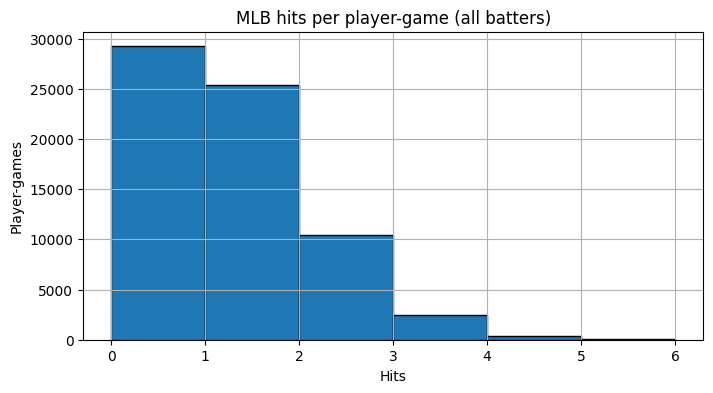

In [13]:
df = q("""
SELECT (pg.stats->>'hits')::int AS hits
FROM player_games pg
JOIN games g USING (game_id)
WHERE g.sport_code='mlb'
  AND (pg.stats->>'plate_appearances')::int > 0;
""")
print(f"Total player-games: {len(df):,}")
print(df["hits"].describe())
df["hits"].hist(bins=range(0, 7), edgecolor='black', figsize=(8, 4))
plt.title("MLB hits per player-game (all batters)")
plt.xlabel("Hits")
plt.ylabel("Player-games")
plt.show()

In [14]:
df = q("""
SELECT p.full_name,
       COUNT(*) AS games,
       AVG((pg.stats->>'hits')::int) AS avg_hits,
       AVG(CASE WHEN (pg.stats->>'hits')::int >= 2 THEN 1.0 ELSE 0.0 END) AS over_15_rate
FROM player_games pg
JOIN players p USING (player_id)
JOIN games g USING (game_id)
WHERE g.sport_code='mlb'
  AND (pg.stats->>'plate_appearances')::int >= 3
GROUP BY p.full_name
HAVING COUNT(*) >= 30
ORDER BY over_15_rate DESC
LIMIT 30;
""")
df

,full_name,games,avg_hits,over_15_rate
0,Bo Bichette,158,1.291139,0.367089
1,Luis Arraez,209,1.253589,0.358852
2,Roman Anthony,67,1.119403,0.358209
3,Joey Loperfido,45,1.088889,0.355556
4,Yandy Díaz,189,1.185185,0.354497
5,Vladimir Guerrero Jr.,224,1.178571,0.348214
6,Daylen Lile,99,1.111111,0.343434
7,Miguel Andujar,102,1.186275,0.343137
8,Jacob Wilson,147,1.170068,0.340136
9,Xavier Edwards,177,1.175141,0.338983


In [15]:
q("""
SELECT p.full_name, pl.sport_code, pl.stat_type, pl.line_value
FROM prop_lines pl
JOIN players p ON p.player_id=pl.player_id
WHERE pl.sportsbook='prizepicks'
  AND pl.line_variant='standard'
  AND pl.sport_code='mlb'
ORDER BY pl.stat_type, p.full_name
LIMIT 30;
""")

,full_name,sport_code,stat_type,line_value
0,Aaron Civale,mlb,earned_runs_allowed,3.5
1,Aaron Civale,mlb,earned_runs_allowed,2.5
2,Braxton Ashcraft,mlb,earned_runs_allowed,3.5
3,Braxton Ashcraft,mlb,earned_runs_allowed,1.5
4,Braxton Ashcraft,mlb,earned_runs_allowed,0.5
5,Emmet Sheehan,mlb,earned_runs_allowed,3.5
6,Emmet Sheehan,mlb,earned_runs_allowed,0.5
7,Emmet Sheehan,mlb,earned_runs_allowed,1.5
8,Joe Ryan,mlb,earned_runs_allowed,2.5
9,Joe Ryan,mlb,earned_runs_allowed,3.5


In [16]:
df = q("""
WITH player_history AS (
    SELECT p.player_id, p.full_name,
           AVG((pg.stats->>'hits')::int) AS avg_hits,
           AVG(CASE WHEN (pg.stats->>'hits')::int >= 2 THEN 1.0 ELSE 0.0 END) AS hist_over_15,
           COUNT(*) AS sample
    FROM player_games pg
    JOIN players p USING (player_id)
    JOIN games g USING (game_id)
    WHERE g.sport_code='mlb'
      AND (pg.stats->>'plate_appearances')::int >= 3
    GROUP BY p.player_id, p.full_name
    HAVING COUNT(*) >= 30
),
current_lines AS (
    SELECT p.player_id, AVG(pl.line_value) AS pp_line
    FROM prop_lines pl
    JOIN players p ON p.player_id=pl.player_id
    WHERE pl.sportsbook='prizepicks'
      AND pl.line_variant='standard'
      AND pl.stat_type='hits'
      AND pl.sport_code='mlb'
    GROUP BY p.player_id
)
SELECT ph.full_name, ph.avg_hits, ph.hist_over_15, ph.sample, cl.pp_line
FROM player_history ph
JOIN current_lines cl USING (player_id)
ORDER BY cl.pp_line DESC, ph.hist_over_15 DESC
LIMIT 50;
""")
df

,full_name,avg_hits,hist_over_15,sample,pp_line
0,Julio Rodríguez,1.097345,0.318584,226,1.5
1,Josh Naylor,1.060185,0.287037,216,1.5
2,J.P. Crawford,0.916256,0.256158,203,1.5
3,Andrew Benintendi,0.935897,0.230769,156,1.5
4,Victor Caratini,0.928571,0.222222,126,1.5
5,Isaac Collins,0.834783,0.200000,115,1.5
6,Kyle Karros,0.720000,0.180000,50,1.5
7,Kyle Isbel,0.801370,0.171233,146,1.5
8,Victor Scott II,0.715278,0.145833,144,1.5
9,Jac Caglianone,0.602941,0.117647,68,1.5


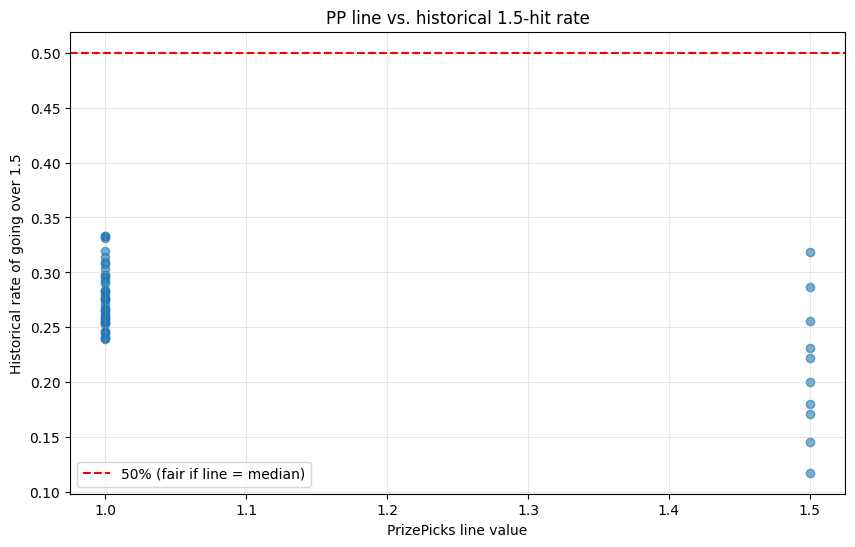

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df["pp_line"], df["hist_over_15"], alpha=0.6)
plt.axhline(0.5, color='red', linestyle='--', label='50% (fair if line = median)')
plt.xlabel("PrizePicks line value")
plt.ylabel("Historical rate of going over 1.5")
plt.title("PP line vs. historical 1.5-hit rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
df_k = q("""
SELECT p.full_name,
       COUNT(*) AS starts,
       AVG((pg.stats->>'strikeouts_pitcher')::int) AS avg_k,
       AVG((pg.stats->>'outs_recorded')::int / 3.0) AS avg_ip
FROM player_games pg
JOIN players p USING (player_id)
JOIN games g USING (game_id)
WHERE g.sport_code='mlb'
  AND (pg.stats->>'batters_faced')::int >= 15
GROUP BY p.full_name
HAVING COUNT(*) >= 15
ORDER BY avg_k DESC
LIMIT 25;
""")
df_k

,full_name,starts,avg_k,avg_ip
0,Tarik Skubal,45,7.866667,6.303704
1,Zack Wheeler,37,7.837838,6.333333
2,Garrett Crochet,37,7.810811,6.189189
3,Cole Ragans,20,7.800000,5.350000
4,Chris Sale,31,7.774194,6.086022
5,Blake Snell,23,7.565217,5.840580
6,Logan Gilbert,39,6.923077,5.495726
7,Hunter Greene,20,6.900000,5.816667
8,Paul Skenes,42,6.833333,5.825397
9,Jacob Misiorowski,17,6.823529,5.156863
